### Detecting High-Speed Streams (HSS)

High-speed enhancements (HSS/SIR events) are detected with the Jian et al. (2006)-style algorithm in [`src/utils/hse_detection.py`](../src/utils/hse_detection.py) (`detect_HSE_blocks`): candidate points where speed rises >50 km/s over 24h, grouped into contiguous blocks, each refined to a (Vmin, Vmax) SIR using the surrounding +/-1-2 day window, then merged/filtered by minimum amplitude and duration.

This method needs the **speed profile itself** to find the local minima/maxima it operates on, so we look at that first -- both the full 2010-2024 period (below) and, for the paper, three representative CR windows in [`figures/figure4_speed_profiles_cr.png`](../figures/figure4_speed_profiles_cr.png) (currently without EUV context panels; may be extended later).

In [1]:
import os, sys
sys.path.append(os.path.abspath("../src"))

import matplotlib.pyplot as plt

from evaluation.model_comparison import build_comparison_df
from evaluation.hss_events import (
    add_formula_uncertainty_band, evaluate_event_detection, match_peaks, peak_bias_stats,
)
from utils.icme import fetch_icme_events
from viz.hss_events import (
    plot_speed_profile_by_year, plot_confusion_matrix, plot_peak_bias,
)

df, cr_df = build_comparison_df(data_dir="../data")
df = add_formula_uncertainty_band(df)
icme_intervals = fetch_icme_events()

series_specs = [
    ("best_sr", "SR-derived formula"),
    ("eswf2", "ESWF"),
    ("wsa_enlil", "WSA-ENLIL"),
    ("speed_p27", "Persistence (27 days)"),
]

---

#### 1. Full-period speed profile (2010-2024)

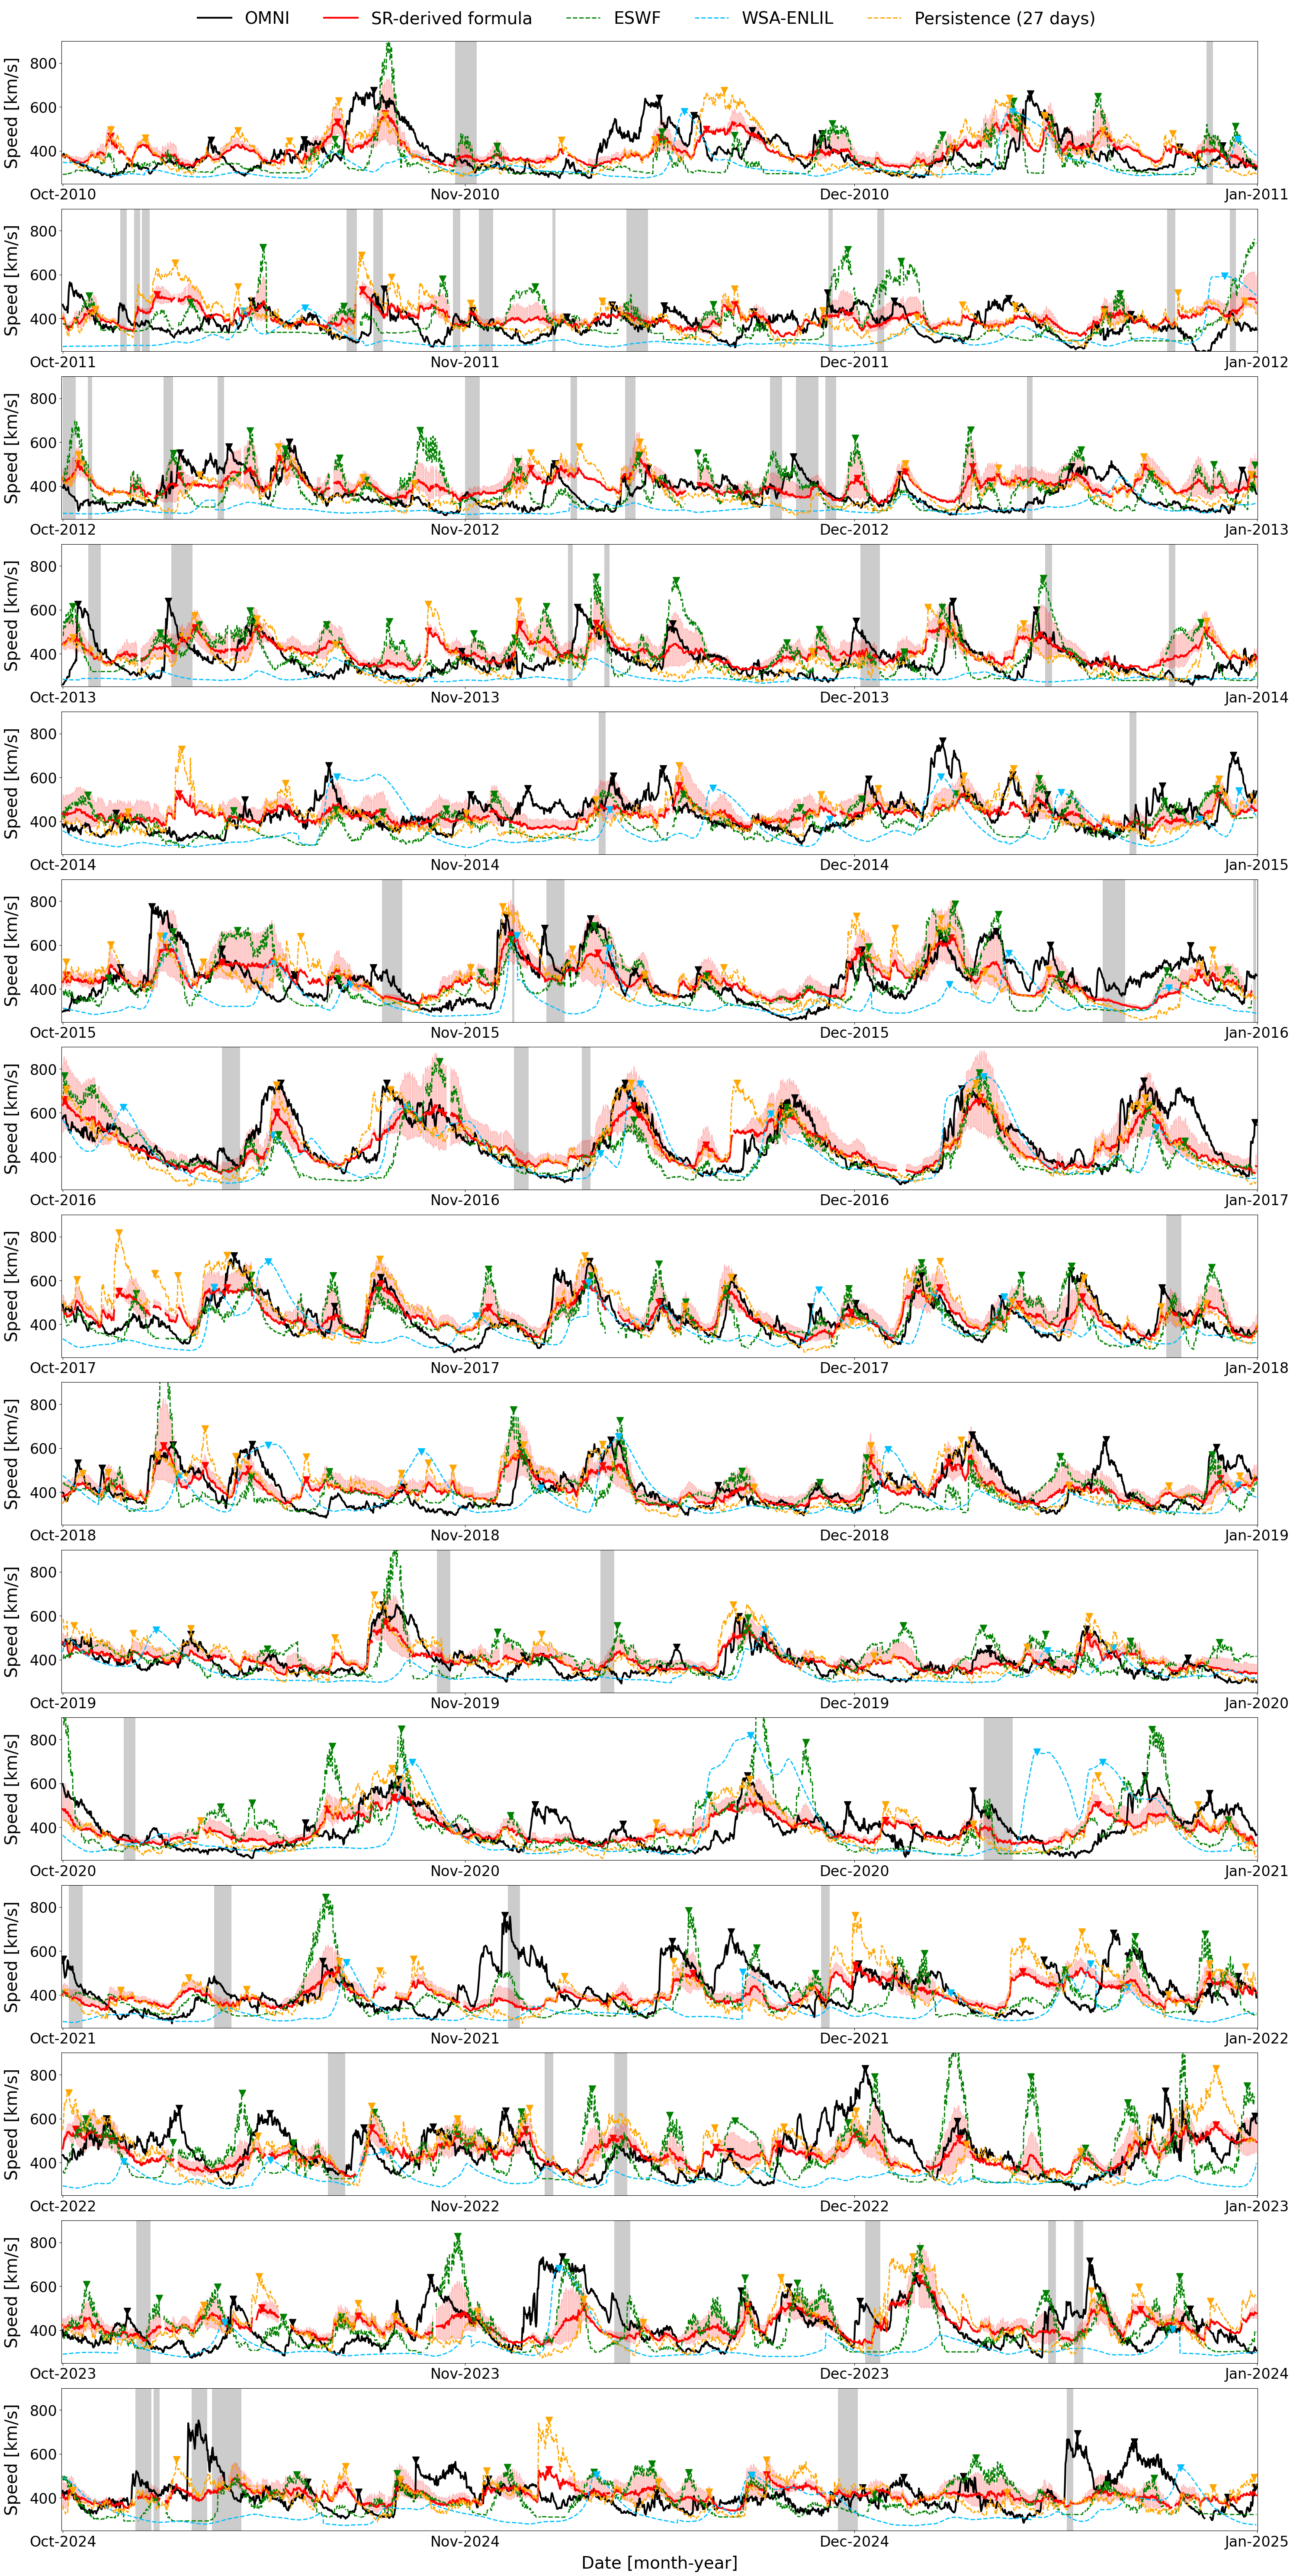

Detected peaks per series:
  SR-derived formula       : 104
  ESWF                     : 183
  WSA-ENLIL                : 66
  Persistence (27 days)    : 183
  OMNI                     : 165


In [2]:
fig, all_peak_lists = plot_speed_profile_by_year(df, series_specs, icme_intervals)
plt.show()

print("Detected peaks per series:")
for label, peaks in all_peak_lists.items():
    print(f"  {label:<25}: {len(peaks)}")

---

#### 2. Event-detection metrics

A model's peak counts as a hit (TP) if it falls within a time window of an OMNI peak; POD/FAR/CSI/BS come from [`src/utils/metrics.py`](../src/utils/metrics.py).

In [3]:
event_df = evaluate_event_detection(all_peak_lists, speed_window=2000)
event_df

,TP,FP,FN,POD,FAR,CSI,BS
model,,,,,,,
SR-derived formula,46,58,119,0.28,0.56,0.21,0.63
ESWF,77,106,88,0.47,0.58,0.28,1.11
WSA-ENLIL,25,41,140,0.15,0.62,0.12,0.40
Persistence (27 days),69,114,96,0.42,0.62,0.25,1.11


Confusion matrix (TP/FP/FN -- TN isn't well-defined for peak matching, so it's omitted):

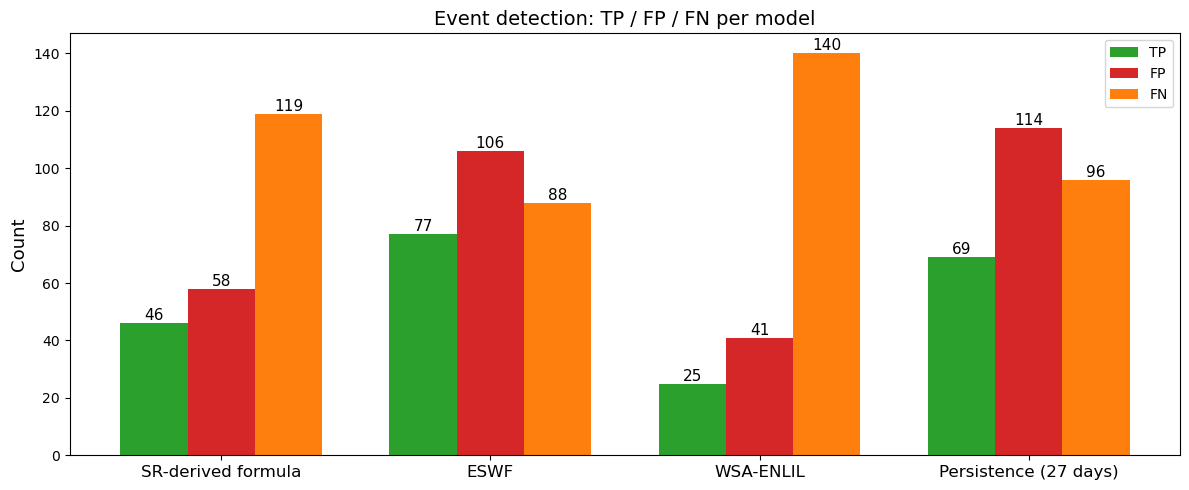

In [4]:
plot_confusion_matrix(event_df)
plt.show()

---

#### 3. Adding a speed constraint to the matching window

The metrics above only require a matched peak to fall within the time window (`speed_window=2000` km/s is effectively unconstrained). Tightening `speed_window` also requires the matched peak's *speed* to be close to OMNI's, which is a stricter definition of "hit". Below: the same time x speed acceptance window drawn directly on the profile (cyan boxes around each OMNI peak), and the resulting metrics with a realistic speed_window=100 km/s.

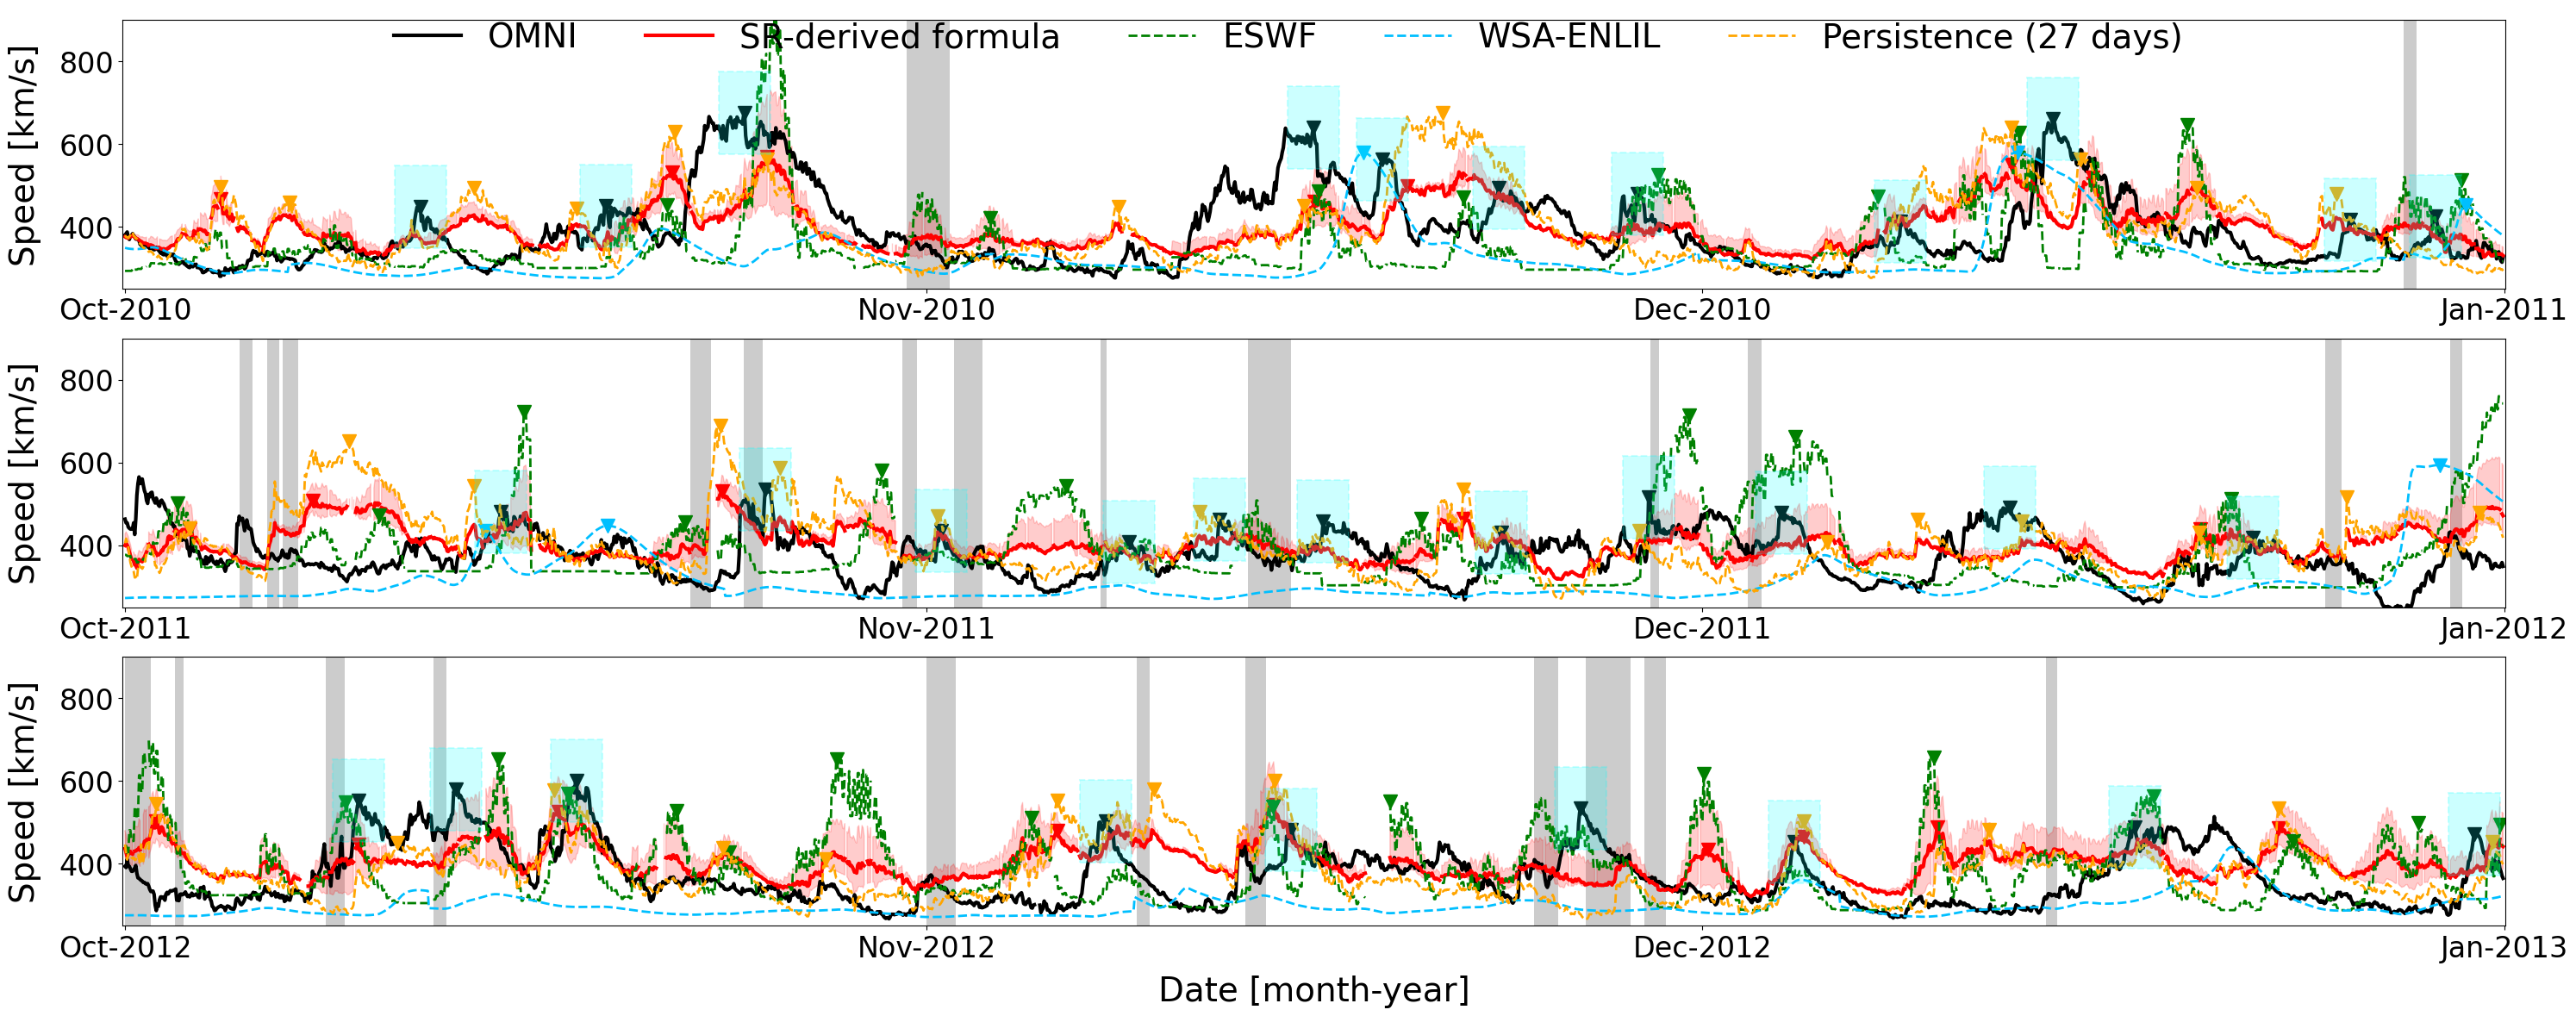

In [5]:
fig, _ = plot_speed_profile_by_year(
    df, series_specs, icme_intervals, years=range(2010, 2013),
    show_event_windows=True, event_time_window_hr=24, event_speed_window=100,
)
plt.show()

With `speed_window=100` applied to the full period:

In [6]:
event_df_strict = evaluate_event_detection(all_peak_lists, speed_window=100)
event_df_strict

,TP,FP,FN,POD,FAR,CSI,BS
model,,,,,,,
SR-derived formula,28,76,137,0.17,0.73,0.12,0.63
ESWF,44,139,121,0.27,0.76,0.14,1.11
WSA-ENLIL,11,55,154,0.07,0.83,0.05,0.40
Persistence (27 days),51,132,114,0.31,0.72,0.17,1.11


---

#### 4. HSS peak bias analysis

For matched peaks (nearest-time pairing within +/-72h, no speed constraint), how early/late and how over/under does each model predict the peak? This is exploratory/diagnostic only and not part of the published figures.

,n_hits,dt_mean_hr,dt_median_hr,dt_std_hr,dt_mae_hr,dt_lead_pct,dt_lag_pct,dt_wilcoxon_p,dv_mean,dv_median,dv_std,dv_mae,dv_over_pct,dv_under_pct,dv_wilcoxon_p
model,,,,,,,,,,,,,,,
SR-derived formula,79,2.95,3.0,29.90,23.94,41.77,54.43,0.36,-64.27,-66.87,76.55,82.41,16.46,83.54,0.00
ESWF,125,7.02,9.0,29.86,24.91,39.20,60.00,0.01,37.99,33.98,135.93,108.49,57.60,42.40,0.01
WSA-ENLIL,52,8.08,17.0,31.61,27.96,34.62,65.38,0.06,-76.90,-86.58,103.09,108.99,25.00,75.00,0.00
Persistence (27 days),117,3.18,1.0,32.56,25.59,48.72,50.43,0.39,-2.83,3.00,93.99,72.13,51.28,47.01,0.81


C:\Users\user\Research\SR_SWspeed\src\viz\hss_events.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


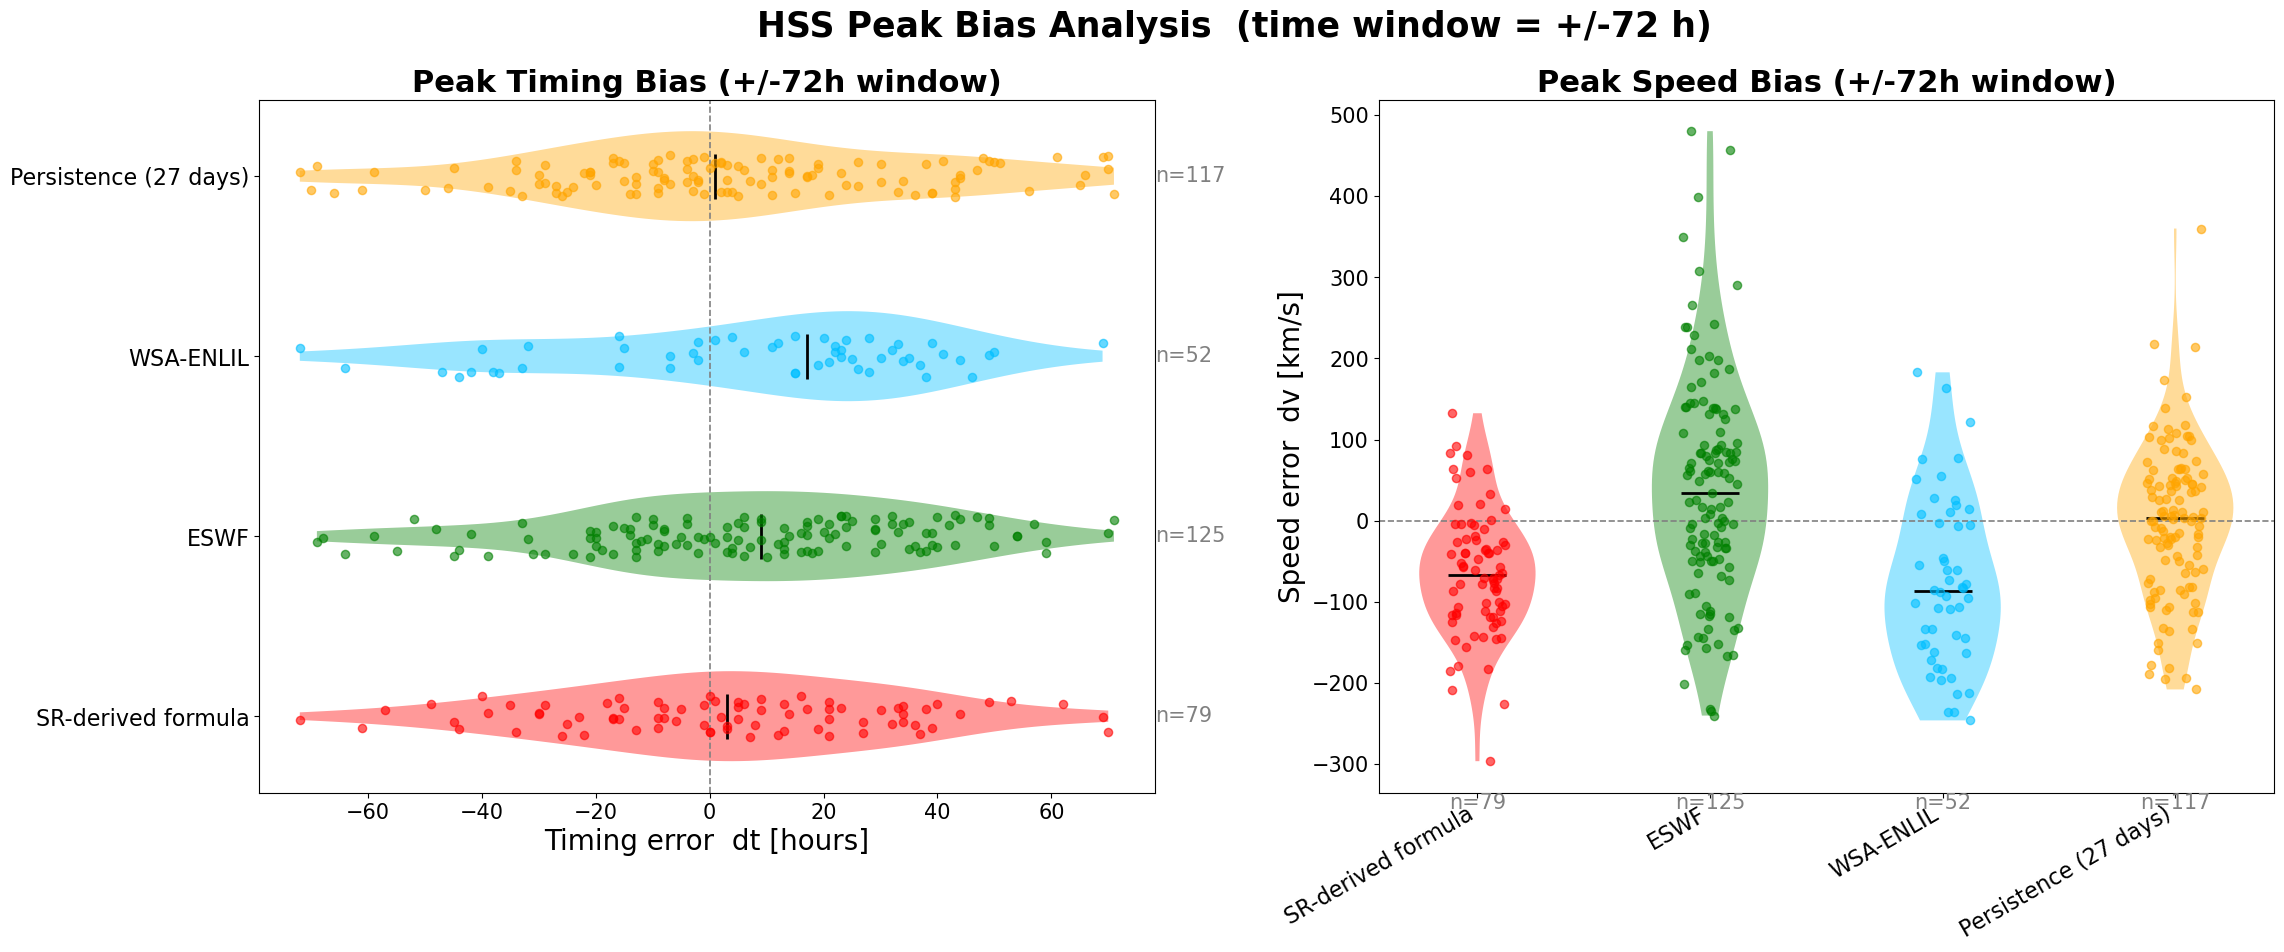

In [7]:
TIME_WINDOW_HR = 72

all_matched = {}
all_stats = []
for _, label in series_specs:
    matched, misses = match_peaks(all_peak_lists["OMNI"], all_peak_lists[label], time_window_hr=TIME_WINDOW_HR)
    all_matched[label] = matched
    all_stats.append(peak_bias_stats(matched, model_name=label))

import pandas as pd
stats_df = pd.DataFrame(all_stats).set_index("model")
display(stats_df[[
    "n_hits", "dt_mean_hr", "dt_median_hr", "dt_std_hr", "dt_mae_hr",
    "dt_lead_pct", "dt_lag_pct", "dt_wilcoxon_p",
    "dv_mean", "dv_median", "dv_std", "dv_mae", "dv_over_pct", "dv_under_pct", "dv_wilcoxon_p",
]].round(2))

plot_peak_bias(all_matched, time_window_hr=TIME_WINDOW_HR)
plt.show()